# Übung 5

**Gruppenname:**

*WMJ*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

werden Sie einen echten Datenfall bearbeiten, der die Firma Tesla betrifft. In diesem Fall werden Sie sich mit dem Thema *Datenaufbereitung* und dessen Konsequenzen beschäftigen. Nach dieser Aufgabe werden Sie sich noch einmal mit explorativer Analyse und Zusammenhangsmaßen (wie beispielsweise der *Mutual Information*) beschäftigen.

### 5.1 Der Fall Tesla: Autopilot

* In diesem Datenfall üben Sie Ihre Fähigkeiten, Datensätze zu erschließen, aufzubereiten und auf Plausibilität zu prüfen.

Seit wenigen Jahren verstärken verschiedene Unternehmen und Startups ihre Bemühungen, autonome Fahrzeuge zu entwickeln. Solche selbststeuerenden Fahrzeuge versprechen eine Vielzahl neuer Anwendungen und haben das Potenzial, unser Verhältnis zu Autos zu verändern. Manche Visionäre sprechen bereits von "mobility as a service", bei der Autos nicht mehr besessen, sondern per App für eine Fahrt geliehen werden und selbstständig fahren.

Bei der Entwicklung von autonomen Fahrzeugen verfolgen verschiedene Hersteller eine schrittweise Strategie, nach der Assistenzfunktionen zum Parken oder für das Halten der Fahrspur nach und nach den Fahrern zur Verfügung gestellt werden. Tesla stellt den sogenannten *Autopilot* bereit, der das Feature *Autosteer* zum automatischen Halten der Fahrspur enthält.

[Im Jahr 2016 verunglückte Joshua Brown](https://www.nytimes.com/2016/07/02/business/joshua-brown-technology-enthusiast-tested-the-limits-of-his-tesla.html) in Florida in einem Tesla Model S, während das Autosteer Feature aktiviert war. Er war damit der erste (soweit bekannte) Todesfall, der in einem selbstfahrenden Auto eingetreten ist.

Die NHTSA, eine Bundesbehörde der USA im Bereich des Verkehrsministeriums, untersuchte den Fall und forderte Zahlen von Tesla an, die die Sicherheit des Autosteering Features belegen sollten. Anhand dieser Zahlen konnte die Behörde im Jahr 2017 folgende Feststellung machen:

![Abbildung](https://data.bialonski.de/ds/tesla_autosteer_nhtsa.png)

Die Anzahl der Airbag-Auslösungen dient dabei als ein Anhaltspunkt für die Anzahl der Unfälle. Dieser Auswertung zufolge reduziert *Autosteer* die Unfallwahrscheinlichkeit um 40%!

Der dieser Statistik zugrundeliegende Datensatz wurde aufgrund eines Antrags basierend auf dem Informationsfreiheitsgesetz der USA (Freedom of Information Act) verfügbar gemacht und steht Ihnen in dieser Übung zur Verfügung.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/tesla.xlsx).


Wir werden die folgenden Eigenschaften [1-6] untersuchen:

1. Kilometerstand (in Meilen) bevor der Installation von Autosteer ("1l Previous Mileage before Autosteer Install").

   * Dieser Wert wurde abgelesen vor Installation von Autosteer.


2. Kilometerstand (in Meilen) nach der Installation von Autosteer ("1l Next Mileage after Autosteer Install")

   * Dieser Wert wurde abgelesen nach Installation von Autosteer.
   
   
3. Gefahrene Meilen vor Autosteer-Installation ("Miles before Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


4. Gefahrene Meilen nach Autosteer Installation ("Miles after Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


5. Airbag-Auslösungen vor Autosteer-Installation ("Airbag events before Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


6. Airbag-Auslösungen nach Autosteer-Installation ("Airbag events after Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


**Ihre Aufgaben**

Für die nachfolgenden Aufgaben benötigen Sie Ihre Neugier und etwas detektivisches Gespür.

(1) Betrachten Sie zunächst mit einer Tabellenkalkulation den oben hinterlegten Datensatz. Suchen Sie nach den oben erwähnten sechs Eigenschaften. 

   * Importieren Sie nun mithilfe von Pandas die oben sechs erwähnten Eigenschaften aus der Excel-Datei. Dabei kann es hilfreich sein, das entsprechende Sheet der Excel-Datei in Pandas anzugeben, aus dem Sie die Daten importieren müssen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
usecols = ["1l Previous Mileage before Autosteer Install", "1l Next Mileage after Autosteer Install", "Miles before Autosteer", "Miles after Autosteer", "Airbag events before Autosteer", "Airbag events after Autosteer"]
tesla = pd.read_excel("./data/tesla.xlsx", sheet_name="PE16_007_PRODUCTION DATA", usecols=usecols).fillna(0)

In [3]:
tesla = tesla[:-4]

(2) Von wie vielen Fahrzeugen wurden Daten erhoben? Nennen Sie die Anzahl der Fahrzeuge, indem Sie sie aus Ihren Daten aus Teilaufgabe (1) bestimmen.

In [4]:
tesla.shape

(43781, 6)

Es wurden die Daten von `43781` Fahrzeugen bestimmt. 

(3) Reproduzieren Sie die beiden Zahlen der NHTSA Behörde der USA, d.h. berechnen Sie die Anzahl der Airbag-Auslösungen vor Autosteer-Installation pro 1 Million gefahrener Meilen und nach Autosteer-Installation pro 1 Million gefahrener Meilen und geben Sie sie an.

   * Wenn Sie nicht auf die Zahlen der NHTSA kommen, lesen Sie diesen [Rot-13](https://rot13.de/index.php) kodierten Hinweis: Süe qvr Orerpuahat ahgmra Fvr ovggr qvr Qngraervura qerv ovf frpuf jvr vz Nofpuavgg "Vuer Qngra" natrtrora.

In [5]:
def plot_airbag(df):
    def diff_key(key_n, key_d, factor=1000000):
        d = df[key_d].sum()
        if d == 0:
            return 0
        return df[key_n].sum()/d * factor
    ax = pd.Series({
        "Vor Autopilot": diff_key("Airbag events before Autosteer", "Miles before Autosteer"),
        "Nach Autopilot": diff_key("Airbag events after Autosteer", "Miles after Autosteer")
    }).plot.bar(width=0.8, color=["#5975A4", "#CC8963"], rot=0, title="Airbag-Auslösungen pro Millionen Meilen", zorder=2)
    
    ax.grid(True, axis="y")

    # ax.bar_label(ax.containers[0], fmt="{:.3f}", label_type="edge")
    label_height = min([bar.get_height() for bar in ax.patches if bar.get_height() > 0]) / 4 * 3
    for bar in ax.patches:
        ax.annotate(
            '{:.1f}'.format(bar.get_height()),
            (bar.get_x() + bar.get_width() / 2, label_height),
            ha="center",
            va="top",
            color="white",
            size=15
        )
    plt.show()

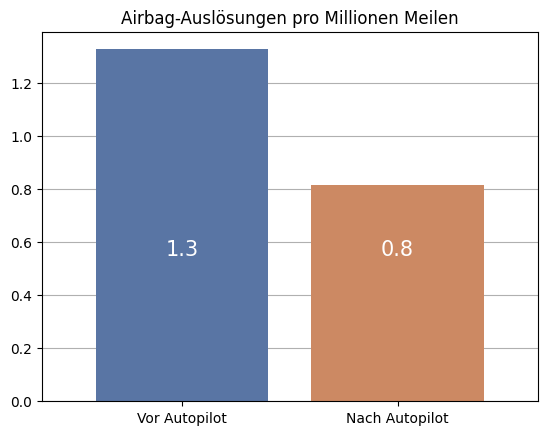

In [6]:
plot_airbag(tesla)


(4) Bis hierher stimmen unsere Analysen mit der US-Behörde überein. Doch es gibt Ungereimtheiten in den Daten. Betrachten Sie dazu die Datenreihen 1 und 2, d.h. die Kilometerstände (in Meilen) der Fahrzeuge vor und nach der Installation von Autosteer. Vor der Installation von Autosteer wird der Kilometerstand erhoben; nach der Installation von Autosteer wird der Kilometerstand erhoben:

1. Welche Erwartungshaltung haben Sie an die beiden Datensätze? (1 Satz)

2. Explorieren Sie diese beiden Datensätze (Stichwort: Explorative Analyse). Was fällt Ihnen auf? (1 Satz)

Wenn Sie partout nicht mehr weiter kommen, gebe ich Ihnen einen Tipp: Jraa Fvr ibe qre Vafgnyyngvba iba Nhgbfgrre qra Xvybzrgrefgnaq nofpuervora jüeqra, haq anpu qre Vafgnyyngvba rorasnyyf qra Xvybzrfgrefgnaq abgvrera, jüeqra fvpu qvr orvqra Xvybzrgrefgäaqr hagrefpurvqra bqre fbyygra fvr tyrvpu frva?

Wir erwarten, dass die Meilen identisch vor und nach der Installation und jeweils echtgrößer 0 sind.

In [7]:
tesla_miles_previous_after_install = tesla[["1l Previous Mileage before Autosteer Install", "1l Next Mileage after Autosteer Install"]]
tesla_miles_previous_after_install.query("(`1l Previous Mileage before Autosteer Install` != `1l Next Mileage after Autosteer Install`) or (`1l Previous Mileage before Autosteer Install` == 0)")

,1l Previous Mileage before Autosteer Install,1l Next Mileage after Autosteer Install
0,0.0,0.0
3,463.0,20147.0
16,733.0,19708.0
18,759.0,33690.0
21,15004.0,17636.0
...,...,...
43776,0.0,2.0
43777,0.0,2.0
43778,0.0,0.0
43779,0.0,0.0


Anscheinend gibt es Daten, die nicht unseren Erwartungen entsprechen.

In [8]:
tesla_miles_previous_after_install.describe()

,1l Previous Mileage before Autosteer Install,1l Next Mileage after Autosteer Install
count,43781.000000,43781.000000
mean,1479.823142,4532.010621
std,3695.992784,6156.846205
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,2092.000000
75%,238.000000,7019.000000
max,57627.000000,97066.000000


In [9]:
tesla_timestamp_known = tesla.query("`1l Previous Mileage before Autosteer Install` == `1l Next Mileage after Autosteer Install`")
tesla_timestamp_unknown = tesla.query("`1l Previous Mileage before Autosteer Install` != `1l Next Mileage after Autosteer Install`")

(5) Problem 1: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie genau feststellen konnten, zu welchem Kilometerstand Autosteer tatsächlich installiert worden sein muss. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die tatsächlich gefahrenen Kilometer (mehr als 0) vor der Autosteer-Installation ausgewiesen wurden.

* Wie viele Fahrzeuge erfüllen die gerade genannten Kriterien?
* Bestimmen Sie die Anzahl der Airbag-Auslösungen pro gefahrenen 1 Million Meilen vor und nach der Installation von Autosteer. Geben Sie diese Zahlen an. Was stellen Sie fest? 
* Vergleichen Sie Ihre Zahlen mit den oben angegebenen Zahlen der NHTSA. Sehen Sie gleiche oder unterschiedliche Tendenzen?

(5719, 6)


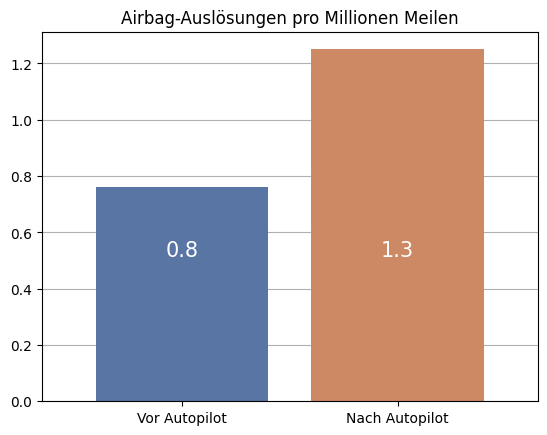

In [10]:
tesla_5_1 = tesla_timestamp_known.query("`Miles before Autosteer` > 0")
print(tesla_5_1.shape)
plot_airbag(tesla_5_1)

- `5719` Fahrzeuge entsprechen den genannten Kriterien.
- Die Tendenzen widersprechen den vorherigen Daten.

(6) Problem 2: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie genau feststellen konnten, zu welchem Kilometerstand Autosteer tatsächlich installiert worden sein muss. Betrachten Sie nun alle Fahrzeuge aus dieser Menge, die **keine gefahrenen Kilometer vor der Autosteer-Installation** aufweisen.

* Wie viele Fahrzeuge erfüllen die gerade genannten Kriterien?
* Wie viele Airbag-Auslösungen vor der Installation von Autosteer beobachten Sie für diese Gruppe von Fahrzeugen?
* Welche Auswirkung hat Ihre Beobachtung auf die Größe der Anzahl an Airbag-Auslösungen pro 1 Million gefahrener Meilen, wie sie die NHTSA berechnet hat?

(14877, 6)


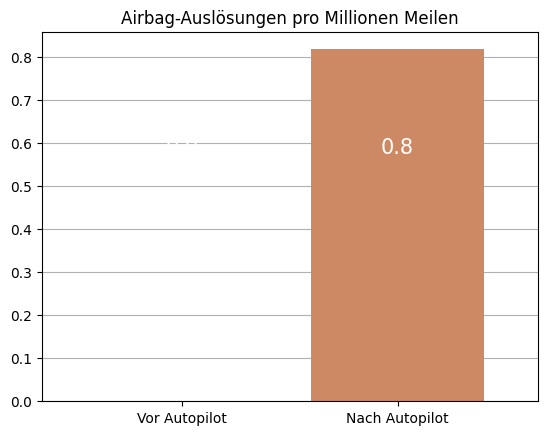

In [11]:
tesla_5_2 = tesla_timestamp_known.query("`Miles before Autosteer` == 0")
print(tesla_5_2.shape)
plot_airbag(tesla_5_2)

- `14877` Fahrzeuge entsprechen den genannten Kriterien.
- Die Tendenzen widersprechen den vorherigen Daten.
- Offensichtlich kann es keinen Unfall vor der Installation gegeben haben, da das Fahrzeug vor der Installation keine Meile zurückgelegt hat.

(7) Problem 3: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie **nicht** genau feststellen können, zu welchem Kilometerstand Autosteer tatsächlich installiert wurde. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die tatsächlich mehr als 0 gefahrene Kilometer vor der Autosteer-Installation ausgewiesen wurden.

1. Wie viele Autos sind in dieser Menge enthalten? Wie viele Airbag-Auslösungen sind in dieser Menge enthalten?
2. Bestimmen Sie die Gesamtanzahl der gefahrenen Meilen über alle Fahrzeuge dieser Menge, die zwischen dem Kilometerstand vor Autosteer-Installation und nach Autoinstallation gefahren wurden. Dies sind die "Gap"-Meilen, bei denen wir nicht wissen, zu welcher exakten Kilometerstandszahl Autosteer installiert wurde.
3. Bestimmen Sie die Gesamtanzahl aller Meilen dieser Menge, die vor der Autosteer-Installation gefahren wurden. 
4. Vergleichen Sie die Zahlen aus Schritt 7.2 und 7.3: Ist die gefahrene Gesamtmeilenzahl vor Autosteer-Installation deutlich größer oder kleiner als die Gesamtmeilenzahl der "Gap"-Meilen?

Welchen Schluss ziehen Sie für die Validität der NHTSA Untersuchung aus Ihren Beobachtungen aus diesem Schritt? (1-3 Sätze).

In [12]:
tesla_5_3 = tesla_timestamp_unknown.query("`Miles before Autosteer` > 0")

print("shape: ", tesla_5_3.shape)
print("airbag:", tesla_5_3["Airbag events before Autosteer"].sum() + tesla_5_3["Airbag events after Autosteer"].sum())
print("gap:   ", (tesla_5_3["1l Next Mileage after Autosteer Install"] - tesla_5_3["1l Previous Mileage before Autosteer Install"]).sum())
print("before:", tesla_5_3["1l Previous Mileage before Autosteer Install"].sum())

shape:  (8920, 6)
airbag: 81.0
gap:    57900319.0
before: 22726819.0


1. `8920` Fahrzeuge entsprechen den genannten Kriterien; `81` Airbag Auslösungen sind in dieser Menge enthalten.
2. Die Summe aller Gap-Meilen beträgt `57900319`.
3. Die Summe aller Meilen, welche vor der Installation gefahren wurden, beträgt `22726819`.
4. Die Summe aller Gap-Meilen ist deutlich größer, als die Summe aller Meilen, welche vor der Installation gefahren wurden.

(8) Problem 4: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie **nicht** genau feststellen können, zu welchem Kilometerstand Autosteer tatsächlich installiert wurde. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die nur 0 gefahrene Kilometer vor der Autosteer-Installation ausgewiesen wurden.

1. Wie viele Autos sind in dieser Menge enthalten?
2. Wie viele Airbag-Auslösungen können Sie vor und nach der Autosteer-Installation feststellen?

Wie deuten Sie Ihre Beobachtungen hinsichtlich der Validität der NHTSA Untersuchung? (1-3 Sätze)

In [13]:
tesla_5_4 = tesla_timestamp_unknown.query("`Miles before Autosteer` == 0")
print("shape:", tesla_5_4.shape)
print(tesla_5_4[["Airbag events before Autosteer", "Airbag events after Autosteer"]].sum())

shape: (14265, 6)
Airbag events before Autosteer    15.0
Airbag events after Autosteer     47.0
dtype: float64


1. `14265` Fahrzeuge entsprechen den genannten Kriterien.
2. Wir können `15` Airbag events vor und `47` Airbag events nach der Installation feststellen.

Da Daten existieren, die Airbag events vor der Installation von Autosteer zeigen, sind anscheinend eine unbekannte Menge an fehlerhaften Daten vorhanden.
Hier muss es sich natürlich nicht um boshaftes Verhalten handeln, sondern die Daten können beispielsweise bei Unfällen auf Autotransportern entstanden sein.

(9) Abschluss: Betrachten Sie Ihre Ergebnisse zu Problemen 1-4. Lässt sich aufgrund der vorliegenden Zahlen die Aussage treffen, dass durch Autosteer die Anzahl der Airbag-Auslösungen pro gefahrene 1 Million Meilen zurückgegangen ist und damit das Fahren sicherer geworden ist? Argumentieren Sie in wenigen Sätzen.

Die relevantesten Daten sind mMn. die Daten, für die wir den genauen Zeitpunkt der Autosteer Installation herausfinden können, die jedoch mehr als 0 gefahrene Meilen vor der Installation haben.
Diese widersprechen dem gegebenen Diagramm stark.

Da man die Daten, für die kein genauer Zeitpunkt der Installation bestimmt werden kann, ebenfalls als Fehlerhaft ansehen könnte, sinkt die Glaubwürdigkeit des gesamten Datensatzes.

Ein interessantes Diagramm wäre potentiell die Auslösung der Airbags auf allen Daten, für die ein genauer Zeitpunkt bestimmt werden kann.

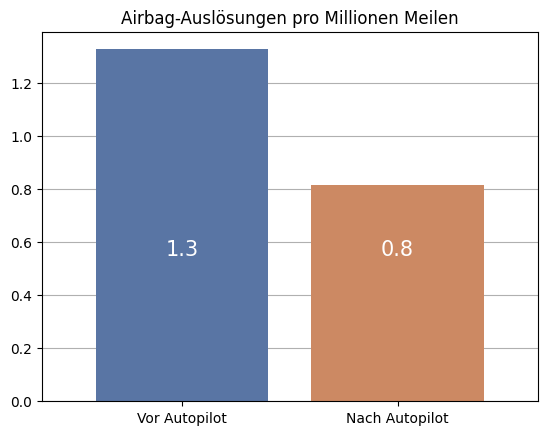

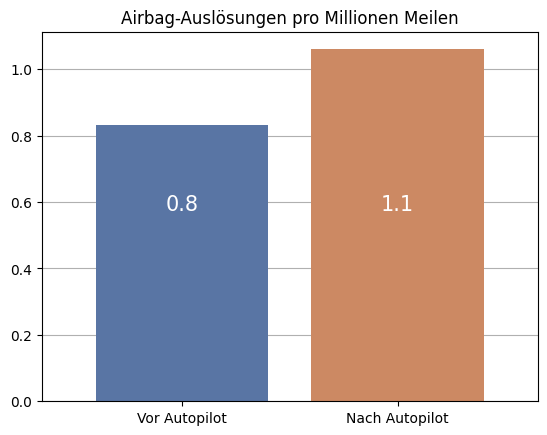

In [14]:
plot_airbag(tesla)
plot_airbag(tesla_timestamp_known)

Laut diesen Daten (unten) sind selbstfahrende Autos nicht sicherer geworden.
Welche Daten schlussendlich korrekt sind, sollte ein Experte in dem Kontext selbstfahrender Autos beurteilen.

### 5.2 Zusammenhangsmaße (Teil 1): Spearman vs Pearson

In dieser Übung werden wir synthetische Daten generieren und damit Spearmans- und Pearsons Korrelationskoeffizienten untersuchen.

**Ihre Daten**

Bei den Daten handelt es sich um die berühmte Fibonacci-Folge, eine unendliche Folge, die vom italienischen Mathematiker Leonardo Fibonacci im 12. Jahrhundert zur Beschreibung der Entwicklung einer Kaninchenpopulation aufgestellt wurde. 

Sei $y_n$ das n-te Glied der Folge und seien $y_1 = 0$ und $y_2 = 1$. Dann ist $y_n$ für $n\geq 3$ definiert als $$y_n = y_{n-1} + y_{n-2}.$$


**Ihre Aufgaben**

Nutzen Sie hauptsächlich Numpy (und ein wenig Pandas) zur Bearbeitung dieser Aufgaben.

(1) Schreiben eine Funktion, die für einen gegebenen Wert $n\in\mathbb{N}$ das Glied der Fibonacci-Folge zurückgibt.

In [15]:
def fib(n, as_folge=False):
    if as_folge:
        if n <= 1:
            return n
        return fib(n-2) + fib(n-1)

    return int(1/np.sqrt(5) * (((1+np.sqrt(5))/2)**n - ((1-np.sqrt(5))/2)**n))

(2) Erzeugen Sie Ihren Datensatz. Sei $n = \{1, \ldots, 30\}$. Erstellen Sie mit Ihrer Funktion aus Schritt (1) die Folge $y_n$ für alle $n$. Sie erhalten damit Wertepaare $(n, y_n)$, die Sie z.B. in einem Numpy Array hinterlegen können.

In [16]:
fib_1_to_30 = pd.Series([fib(n) for n in range(0, 31)], index=range(0, 31))

(3) Schlagen Sie die Definition des Pearson Korrelationskoeffizienten in der Vorlesung nach und implementieren Sie eine Funktion, die zwei Datenreihen entgegennimmt und Pearsons Korrelationskoeffizient zurückgibt.

In [17]:
def index(x, X_sorted):
    i_0 = X_sorted.index(x)

    i_n = i_0
    for i_n in range(i_0+1, len(X_sorted)):
        if X_sorted[i_0] != X_sorted[i_n]:
            i_n -= 1
            break

    return sum([i for i in range(i_0, i_n+1)]) / (i_n - i_0 + 1) + 1
    
def rank(X):
    X_sorted = sorted(X)
    return [index(x, X_sorted) for x in X]

def corr(X, Y, method="pearson"):
    if len(X) != len(Y):
        raise ValueError
        
    if method == "pearson":
        x_mean = 1/len(X) * sum(X)
        y_mean = 1/len(Y) * sum(Y)

        s_X = np.sqrt(1/(len(X)-1) * sum([(x - x_mean)**2 for x in X]))
        s_Y = np.sqrt(1/(len(Y)-1) * sum([(y - y_mean)**2 for y in Y]))

        s_XY = 1/(len(X)-1) * sum([(X[i]-x_mean)*(Y[i]-y_mean) for i in range(len(X))])

        return s_XY/(s_X*s_Y)
    
    elif method == "spearman":
        return corr(rank(X), rank(Y))

    else:
        raise NotImplementedError

(4) Bestimmen Sie dann den Pearson Korrelationskoeffizienten zwischen der Datenreihe ${n}$ und ${y_n}$ mithilfe Ihrer Funktion aus (3) und notieren Sie sich den Wert.

In [18]:
corr(fib_1_to_30.index.values, fib_1_to_30.values)

0.5952256692683904

(5) Schlagen Sie in den Vorlesungsfolien die Definition von Spearmans Korrelationskoeffizienten nach. Kopieren Sie sich den Code aus Schritt (3) und erzeugen Sie daraus eine neue Funktion, die Spearmans Korrelationskoeffizienten implementiert. Um die Ränge zu berechnen, können Sie Pandas `rank` Funktion nutzen.

siehe (3)

(6) Nutzen Sie Ihre Funktion aus Schritt (5), um Spearmans Korrelationskoeffizient zwischen $n$ und $y_n$ zu berechnen, die Sie in Schritt (2) erzeugt hatten.

In [19]:
corr(fib_1_to_30.index.values, fib_1_to_30.values, method="spearman")

0.9998991884669046

(7) Vergleichen Sie den Wert von Pearsons Korrelationskoeffizienten (aus Schritt 4) mit dem Wert von Spearmans Korrelationskoeffizienten (aus Schritt 6). Was fällt Ihnen auf? (1 Satz). Was ist die Ursache für den Unterschied zwischen beiden Werten, den Sie feststellen? (1-3 Sätze)  

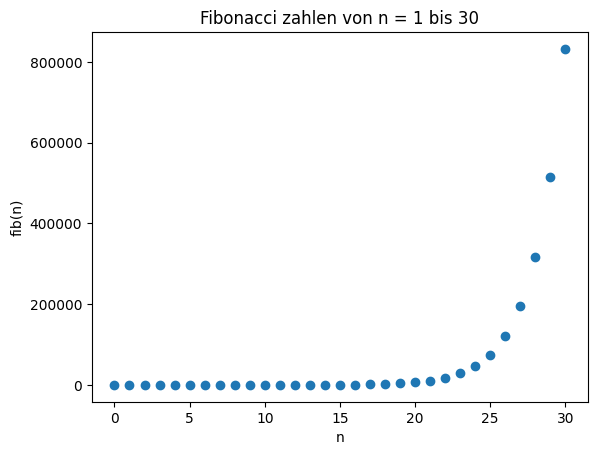

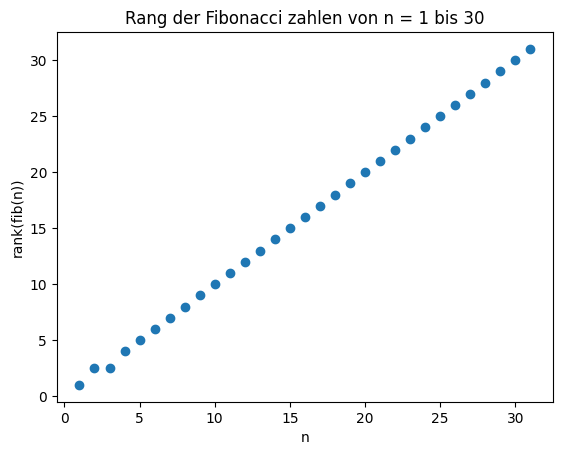

In [20]:
plt.scatter(fib_1_to_30.index, fib_1_to_30.values)
plt.title("Fibonacci zahlen von n = 1 bis 30")
plt.xlabel("n")
plt.ylabel("fib(n)")
plt.show()
plt.scatter(rank(fib_1_to_30.index), rank(fib_1_to_30.values))
plt.title("Rang der Fibonacci zahlen von n = 1 bis 30")
plt.xlabel("n")
plt.ylabel("rank(fib(n))")
plt.show()

Wir sehen, dass der `Rang der Fibonacci Zahlen von 1 bis 30` eine nahezu perfekte Gerade ergibt, also ein sehr starker linearer Zusammenhang existiert.

Dei Fibonacci Zahlen an sich erinnern jedoch eher an einen exponentiellen Zusammenhang, sind also nicht linear Abhängig.

Sollten wir den Spearman Rang der Fibonacci Zahlen ab `n = 2` errechnen, erhalten wir den höchsten möglichen Wert `1`.

Pearson Korrelationskoeffizient:  0.1590645136680469
Spearman Korrelationskoeffizient: 1


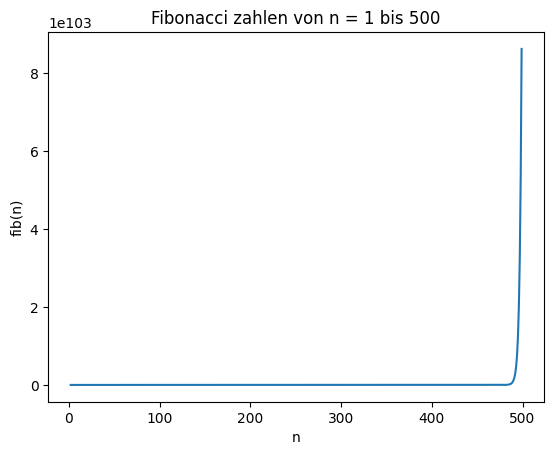

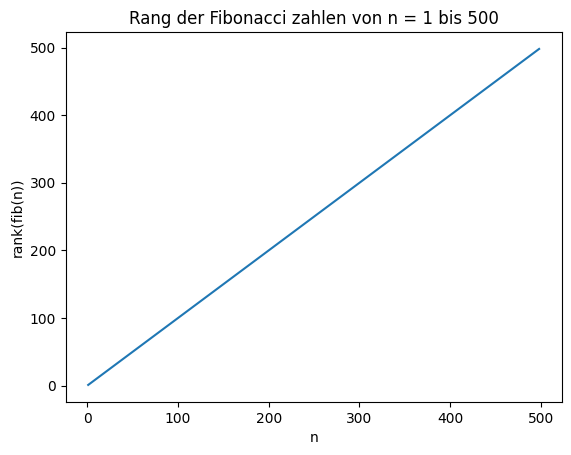

In [21]:
n = 500

fib_2_to_n = pd.Series([fib(x) for x in range(2, n)], index=range(2, n))

print("Pearson Korrelationskoeffizient: ", corr(fib_2_to_n.index.values, fib_2_to_n.values))
print("Spearman Korrelationskoeffizient:", int(corr(fib_2_to_n.index.values, fib_2_to_n.values, method="spearman")))

plt.plot(fib_2_to_n.index, fib_2_to_n.values)
plt.title(f"Fibonacci zahlen von n = 1 bis {n}")
plt.xlabel("n")
plt.ylabel("fib(n)")
plt.show()
plt.plot(rank(fib_2_to_n.index.values), rank(fib_2_to_n.values))
plt.title(f"Rang der Fibonacci zahlen von n = 1 bis {n}")
plt.xlabel("n")
plt.ylabel("rank(fib(n))")
plt.show()

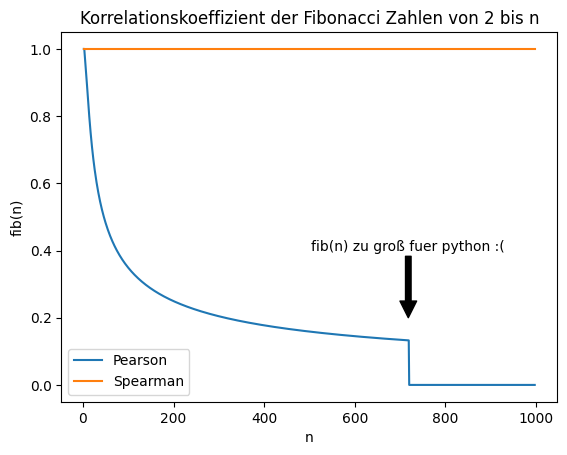

In [22]:
fib_2_to_500 = pd.DataFrame([[n, fib(n)] for n in range(2, 1000)]).astype(float)

n = range(2, len(fib_2_to_500))

fig, ax = plt.subplots()

plt.plot(n, [fib_2_to_500[:i].corr().loc[0,1] for i in n], label="Pearson")
plt.plot(n, [fib_2_to_500[:i].corr(method="spearman").loc[0,1] for i in n], label="Spearman")

f = [fib_2_to_500[:i].corr().loc[0,1] for i in n].index(0)
ax.annotate('fib(n) zu groß fuer python :(', xy=(f, 0.2), xytext=(f, 0.4), ha="center", arrowprops=dict(facecolor='black'))

plt.title("Korrelationskoeffizient der Fibonacci Zahlen von 2 bis n")
plt.xlabel("n")
plt.ylabel("fib(n)")
plt.legend()
plt.show()

### 5.3 Zusammenhangsmaße (Teil 2): Mutual Information, Pearson, Spearman

In dieser Übung werden Sie Zusammenhänge zwischen verschiedenen Datensätzen mithilfe der Zusammenhangsmaße untersuchen, die Sie in der Vorlesung kennengelernt haben. Daneben werden Sie vertraut mit dem Importieren von Daten aus Excel-Tabellen.

* Nutzen Sie Pandas und Numpy zum Bearbeiten der folgenden Aufgaben.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, [hier](https://data.bialonski.de/ds/dependency_data.xlsx).

**Ihre Aufgaben**

(1) Importieren Sie die Daten mithilfe der [Funktionalität](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html) von Pandas in einen DataFrame.

* Visualisieren Sie die Daten zunächst **nicht** (aus didaktischen Gründen). Sie werden die Daten erst im Teilschritt (5) visualisieren.

In [23]:
dependency_data = pd.read_excel("./data/dependency_data.xlsx", index_col=0)

(2) Wir betrachten im Folgenden Paare von Spalten, beispielsweise $(X, y_1)$, die wir *Datenreihenpaare* nennen werden.

Berechnen Sie mit Ihrem Code aus Übung 4 den Pearson- sowie den Spearman-Korrelationskoeffizienten für die Datenreihenpaare ...

1. $(X, y_1)$
2. $(X, y_2)$
3. $(X, y_3)$
4. $(X, y_4)$

In [24]:
Y = [f"y{n}" for n in range(1, 5)]
pd.DataFrame({
    "pearson": [corr(dependency_data["X"], dependency_data[y]) for y in Y],
    "spearman": [corr(dependency_data["X"], dependency_data[y], method="spearman") for y in Y]
}, index=[f"(X, {y})" for y in Y])

,pearson,spearman
"(X, y1)",0.017645,0.041928
"(X, y2)",0.034779,0.036213
"(X, y3)",0.329043,-0.726994
"(X, y4)",0.018458,0.018700


(3) Beantworten Sie - ohne zu Visualisieren - anhand der Koeffizienten aus Teilaufgabe (2):

* Welche der Datenreihenpaare zeigen Korrelationen? Welche Datenreihenpaare sind unkorreliert?
* Gibt es Widersprüche zwischen den Korrelationskoeffizienten? Falls ja, für welche Daten?

Laut `Pearson` sind ausschließlich `(X, y3)` leicht korreliert.

Laut `Spearman` sind ebenfalls ausschließlich `(X, y3)` korreliert, jedoch deutlich stärker und was stark verwunderlich ist, negativ.

(4) Bestimmen Sie nun für die in Teilaufgabe (2) genannten Datenreihenpaare jeweils die Mutual Information. Ausgehend von Ihren Werten für die Mutual Information beantworten Sie bitte: Zwischen welchen Datenreihenpaaren gibt es Zusammenhänge, zwischen welchen Datenreihenpaare gibt es keine (großen) Zusammenhänge?

* Nutzen Sie für die Bestimmung der *Mutual Information* die [Implementierung](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html) der scikit-learn Bibliothek. Hintergrund: Eine robuste Schätzung der Mutual Information ist anspruchsvoll und wurde von verschiedenen Forschungsgruppen untersucht. Einer der [weltweit bekanntesten Schätzer](https://journals.aps.org/pre/pdf/10.1103/PhysRevE.69.066138) der Mutual Information wurde von Forschern des Forschungszentrum Jülichs (am John von Neumann-Institut für Computing) im Jahr 2004 publiziert und wird auch von scikit-learn implementiert.

In [25]:
from sklearn.feature_selection import mutual_info_regression

pd.DataFrame({
    "mutual_information": [mutual_info_regression(dependency_data["X"].values.reshape(-1, 1), dependency_data[y])[0] for y in Y],
}, index=[f"(X, {y})" for y in Y])

,mutual_information
"(X, y1)",0.846372
"(X, y2)",0.886646
"(X, y3)",2.548904
"(X, y4)",0.020669


`(X, y4)` sind augenscheinlich keinen Zusammenhang.

`(X, y1)` und `(X, y2)` besitzen jeweils einen kleinen Zusammenhang.

Wie bereits vermutet, hat `(X, y3)` den größten Zusammenhang.

(5) Visualisieren Sie nun alle Datenreihenpaare aus Teilaufgabe (2) in Scatterplots und beschriften Sie jeden Plot mit den entsprechenden Werten des Pearson-, Spearman-Korrelationskoeffizienten und dem Wert der Mutual Information.

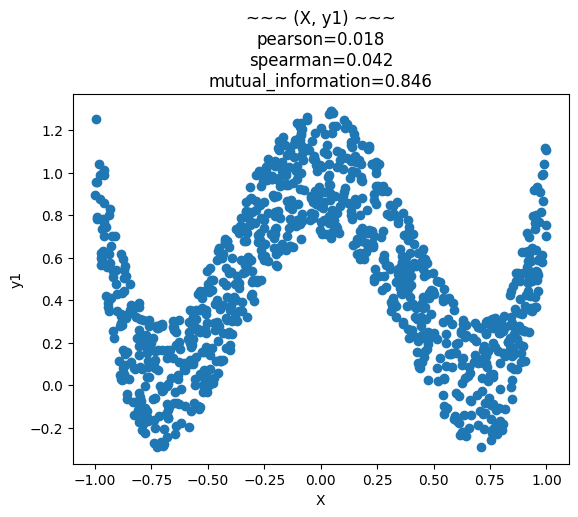

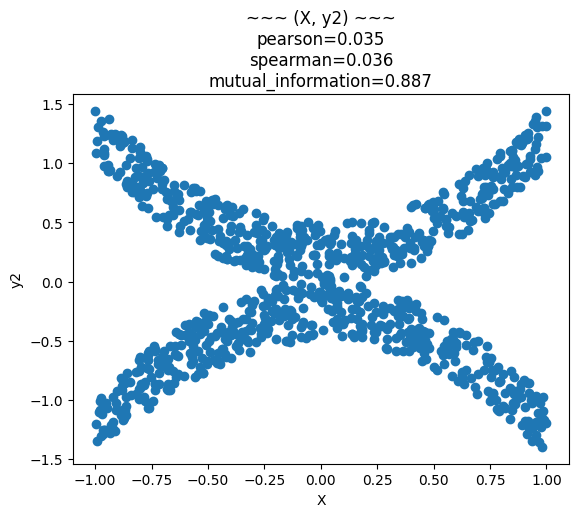

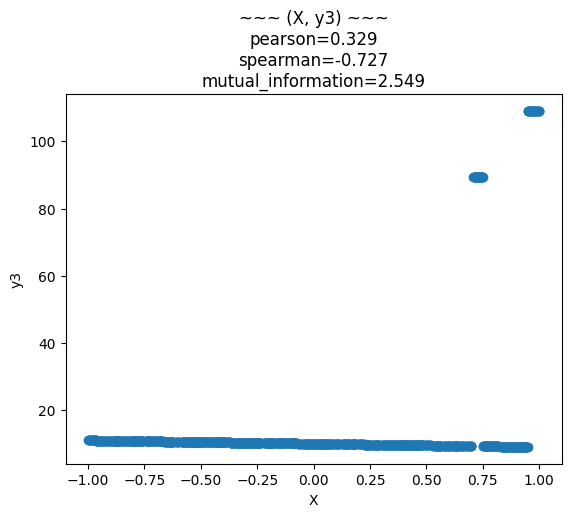

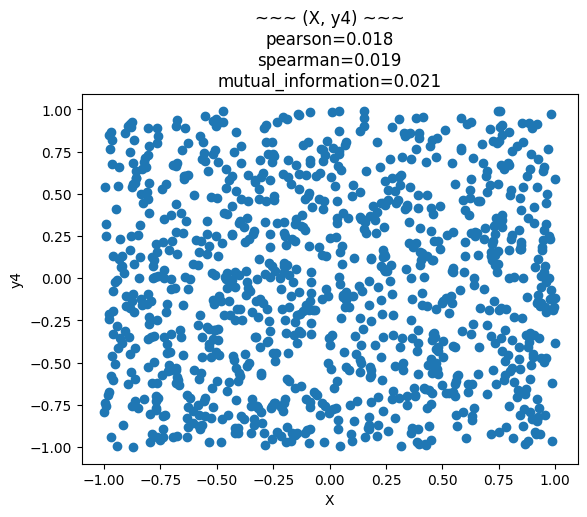

In [26]:
for y in Y:
    plt.scatter(dependency_data["X"], dependency_data[y])
    plt.title(f"""~~~ (X, {y}) ~~~
pearson={corr(dependency_data["X"], dependency_data[y]):.3f}
spearman={corr(dependency_data["X"], dependency_data[y], method="spearman"):.3f}
mutual_information={mutual_info_regression(dependency_data["X"].values.reshape(-1, 1), dependency_data[y])[0]:.3f}""")
    
    plt.xlabel("X")
    plt.ylabel(y)
    plt.show()

(6) Begründen Sie nun für jedes Datenreihenpaar, warum Sie Korrelationen oder keine Korrelation durch Pearson, Spearman und die Mutual Information angezeigt bekommen.

* Begründen Sie zusätzlich, warum Sie für Datenreihenpaar $(X, y_3)$ so unterschiedliche Ergebnisse für den Pearson- und den Spearman-Korrelationskoeffizienten erhalten haben.

Am offensichtlichsten sind erneut `(X, y4)`. Hierbei handelt es sich um eine reine Datenwolke.

`(X, y1)` und `(X, y2)` haben keinen linearen Zusammenhang.
Man kann jedoch erkennen, dass die Werte anderweitig zusammenhängen.

Der mMn. spannendste Datensatz ist `(X, y3)`.
Da es einige Ausreißer mit großen Werten gibt, ist der `Pearson Korrelationskoeffizient` positiv, wenn auch betragsmäßg klein.
Die generelle Tendenz der Daten sinkt jedoch.
Dieses Verhalten lässt sich am besten beobachten, wenn man sich den Rang der Daten anschaut:

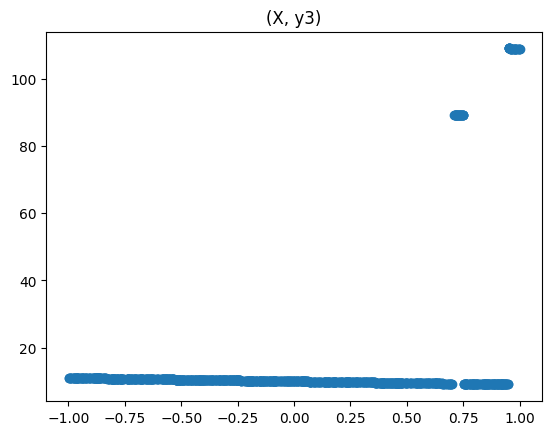

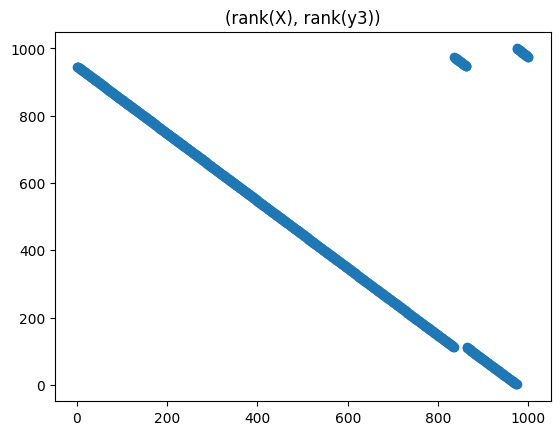

In [27]:
plt.scatter(dependency_data["X"], dependency_data["y3"])
plt.title("(X, y3)")
plt.show()
plt.scatter(rank(dependency_data["X"]), rank(dependency_data["y3"]))
plt.title("(rank(X), rank(y3))")
plt.show()